# 01 — Carga unificada y limpieza

Carga los tres datasets de Conti (Jabber 2020, Jabber 2021-22, Rocket.Chat), los normaliza a un schema común y genera `data/processed/conti_unified.parquet`.

In [1]:
# "sys" es el módulo de Python que da acceso a configuración del intérprete.
# Lo usamos aquí para añadir una carpeta al "path" de Python, que es la lista
# de lugares donde Python busca módulos cuando hacemos "import algo".
import sys

# Path nos permite trabajar con rutas de archivos de forma segura y cómoda.
from pathlib import Path

# Añadimos la carpeta "src/" al path de Python para que podamos importar
# los módulos que están ahí (como loaders.py). Sin esta línea, Python no
# sabría dónde buscar el módulo "loaders".
# str(...) convierte el objeto Path a texto porque sys.path espera strings.
# .resolve() convierte la ruta relativa en absoluta para evitar ambigüedades.
sys.path.insert(0, str(Path('src').resolve()))

# Importamos las funciones de carga que definimos en src/loaders.py.
# Cada función sabe cómo leer un formato distinto de los chats de Conti.
from loaders import load_jabber_2020, load_jabber_2021, load_rocketchat, load_all

# Importamos pandas para trabajar con tablas de datos (DataFrames).
import pandas as pd

# Definimos las rutas a las carpetas de datos.
# RAW_DIR es donde están los archivos originales extraídos.
# PROCESSED_DIR es donde guardaremos los datos limpios y unificados.
RAW_DIR       = Path('../data_Vruto/ContiLeaks/raw')
PROCESSED_DIR = Path('../data_Vruto/ContiLeaks')

# Creamos la carpeta de procesados si no existe.
# parents=True crea también las carpetas intermedias si faltan.
# exist_ok=True evita error si la carpeta ya existe.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Verificamos que la carpeta de datos crudos existe antes de continuar.
print('RAW_DIR existe:', RAW_DIR.exists())

RAW_DIR existe: True


## 1. Carga por fuente — verificación individual

In [2]:
# Cargamos cada fuente de datos por separado para poder verificar que cada una
# se cargó correctamente antes de unirlas todas.

# Jabber 2020: chats del protocolo Jabber del año 2020.
print('Cargando Jabber 2020...')
df_2020 = load_jabber_2020(RAW_DIR)
# len() devuelve el número de filas (mensajes). Los {:,} en el f-string añaden separadores
# de miles para que 107967 se muestre como 107,967 (más fácil de leer).
# .timestamp.min() y .max() devuelven la fecha más antigua y más reciente del dataset.
print(f'  → {len(df_2020):,} mensajes | rango: {df_2020.timestamp.min()} → {df_2020.timestamp.max()}')

# Jabber 2021-2022: chats de Jabber de los años 2021 y parte de 2022.
print('Cargando Jabber 2021-2022...')
df_2021 = load_jabber_2021(RAW_DIR)
print(f'  → {len(df_2021):,} mensajes | rango: {df_2021.timestamp.min()} → {df_2021.timestamp.max()}')

# Rocket.Chat: chats del servidor de mensajería grupal Rocket.Chat que usaba Conti.
print('Cargando Rocket.Chat...')
df_rc = load_rocketchat(RAW_DIR)
print(f'  → {len(df_rc):,} mensajes | rango: {df_rc.timestamp.min()} → {df_rc.timestamp.max()}')

Cargando Jabber 2020...


  → 107,967 mensajes | rango: 2020-06-21 15:09:47.158053+00:00 → 2020-11-16 17:38:31.590878+00:00
Cargando Jabber 2021-2022...
  → 60,749 mensajes | rango: 2021-01-29 00:06:46.929363+00:00 → 2022-02-28 18:38:04.917143+00:00
Cargando Rocket.Chat...


  → 86,168 mensajes | rango: 2020-08-31 10:45:15.536000+00:00 → 2022-02-26 19:05:36.155000+00:00


In [3]:
# Mostramos una muestra de las primeras filas de cada fuente para inspeccionar
# visualmente que los datos se cargaron con el formato correcto: que las columnas
# tienen sentido, que los mensajes son texto legible, etc.

# iteramos sobre una lista de tuplas (nombre, dataframe) para no repetir código.
for label, df in [('Jabber 2020', df_2020), ('Jabber 2021', df_2021), ('Rocket.Chat', df_rc)]:
    print(f'\n--- {label} ---')
    # .head(3) devuelve solo las primeras 3 filas del DataFrame.
    # display() las muestra con formato de tabla en el notebook (más legible que print).
    display(df.head(3))


--- Jabber 2020 ---


,timestamp,username,to_user,message,source,channel
0,2020-06-21 15:09:47.158053+00:00,price,mentos,привет,jabber_2020,185.25.51.173-20200622
1,2020-06-21 15:21:09.214052+00:00,mentos,price,привет,jabber_2020,185.25.51.173-20200622
2,2020-06-21 15:21:33.055319+00:00,price,mentos,"вопрос есть,.",jabber_2020,185.25.51.173-20200622



--- Jabber 2021 ---


,timestamp,username,to_user,message,source,channel
0,2021-01-29 00:06:46.929363+00:00,mango,stern,"про битки не забудь, кош выше, я спать)",jabber_2021,185.25.51.173-20210129
1,2021-01-29 04:04:39.308133+00:00,mango,stern,привет,jabber_2021,185.25.51.173-20210129
2,2021-01-29 04:04:43.474243+00:00,mango,stern,битков не хватит на все..,jabber_2021,185.25.51.173-20210129



--- Rocket.Chat ---


,timestamp,username,to_user,message,source,channel
0,2021-10-25 19:14:35.801000+00:00,gall,GENERAL,@dildoso +,rocketchat,general
1,2021-10-25 18:21:32.487000+00:00,millenium,GENERAL,hitch на связи?,rocketchat,general
2,2021-10-25 17:39:39.692000+00:00,1l1nk,GENERAL,+,rocketchat,general


## 2. Concatenar en dataset unificado

In [4]:
# Unimos los tres DataFrames en uno solo apilándolos verticalmente.
# pd.concat([lista_de_dfs]) pega los DataFrames uno debajo del otro, como
# si pegaras tres hojas de Excel una bajo la otra.
# ignore_index=True vuelve a numerar las filas desde 0 (en vez de mezclar
# los índices originales de cada DataFrame).
df = pd.concat([df_2020, df_2021, df_rc], ignore_index=True)

# Ordenamos todos los mensajes por fecha, del más antiguo al más reciente.
# sort_values('timestamp') ordena por la columna timestamp.
# reset_index(drop=True) vuelve a numerar las filas después de ordenar
# (drop=True descarta el índice anterior para que no se convierta en columna).
df = df.sort_values('timestamp').reset_index(drop=True)

# Mostramos estadísticas globales para verificar que la unión fue correcta.
print(f'Total mensajes: {len(df):,}')
print(f'Rango temporal: {df.timestamp.min()} → {df.timestamp.max()}')

# value_counts() cuenta cuántas filas hay de cada valor único en la columna 'source'.
# .to_string() lo convierte a texto para que se imprima bien (sin truncamiento).
print(f'\nDistribución por fuente:')
print(df.source.value_counts().to_string())

Total mensajes: 254,884
Rango temporal: 2020-06-21 15:09:47.158053+00:00 → 2022-02-28 18:38:04.917143+00:00

Distribución por fuente:
source
jabber_2020    107967
rocketchat      86168
jabber_2021     60749


## 3. Limpieza

In [5]:
# Guardamos el número de filas ANTES de limpiar, para luego poder ver cuántas eliminamos.
n_before = len(df)

# --- Paso 1: Eliminar mensajes vacíos o que solo tienen espacios en blanco ---
# .str.strip() elimina espacios al inicio y al final de cada mensaje.
# .str.len() devuelve la longitud del texto resultante.
# > 0 filtra solo los mensajes con al menos un carácter.
# El resultado es una máscara de True/False que usamos para filtrar el DataFrame.
df = df[df['message'].str.strip().str.len() > 0]

# --- Paso 2: Eliminar mensajes completamente duplicados ---
# Un duplicado exacto es un mensaje con el mismo timestamp, mismo autor y mismo texto.
# Esto puede pasar si los archivos tienen solapamientos.
# drop_duplicates() elimina todas las filas duplicadas excepto la primera.
# subset= indica las columnas que se usan para detectar duplicados.
df = df.drop_duplicates(subset=['timestamp', 'username', 'message'])

# --- Paso 3: Eliminar filas con timestamp inválido ---
# Algunos mensajes pueden tener fecha None o NaT (Not a Time = fecha vacía/inválida).
# dropna(subset=['timestamp']) elimina las filas donde 'timestamp' es nulo.
df = df.dropna(subset=['timestamp'])

# --- Paso 4: Normalizar los nombres de usuario ---
# Los mismos actores pueden aparecer con mayúsculas distintas: "Mango", "MANGO", "mango".
# .str.strip() elimina espacios al inicio y al final.
# .str.lower() convierte todo a minúsculas.
# Esto garantiza que todos los nombres estén en el mismo formato para análisis.
df['username'] = df['username'].str.strip().str.lower()
df['to_user']  = df['to_user'].str.strip().str.lower()

# Volvemos a numerar las filas desde 0 después de todas las eliminaciones.
df = df.reset_index(drop=True)

# Mostramos cuántos mensajes se eliminaron en total durante la limpieza.
print(f'Filas eliminadas en limpieza: {n_before - len(df):,}')
print(f'Mensajes limpios: {len(df):,}')

Filas eliminadas en limpieza: 38,581
Mensajes limpios: 216,303


## 4. Detección de idioma

In [6]:
# Importamos langdetect, una librería que detecta automáticamente el idioma de un texto.
# Internamente usa el mismo algoritmo que Google Translate.
from langdetect import detect, LangDetectException

# tqdm es una librería que muestra una barra de progreso mientras procesamos datos.
# Es muy útil cuando tenemos operaciones lentas sobre muchas filas.
from tqdm.auto import tqdm

def safe_detect(text):
    """
    Intenta detectar el idioma del texto dado y devuelve el código de idioma
    (por ejemplo 'ru' para ruso, 'en' para inglés).
    Si la detección falla (texto muy corto, emojis, etc.), devuelve 'und' (undetermined).
    Solo mira los primeros 200 caracteres para ser más rápido.
    """
    try:
        # detect() devuelve un código de idioma de dos letras: 'ru', 'en', 'uk', etc.
        # str(text)[:200] convierte el mensaje a texto y toma solo los primeros 200 caracteres.
        return detect(str(text)[:200])
    except LangDetectException:
        # LangDetectException se lanza cuando el texto es demasiado corto o ambiguo.
        # Devolvemos 'und' (undetermined = indeterminado) como valor por defecto.
        return 'und'

# Configuramos tqdm para que muestre una barra de progreso cuando usemos
# progress_apply() en vez de apply(). Esto es útil porque la detección de idioma
# tarda varios minutos con 200,000 mensajes.
tqdm.pandas(desc='Detectando idioma')

# Aplicamos la función safe_detect a cada mensaje de la columna 'message'.
# progress_apply() es igual que .apply() pero muestra la barra de progreso.
# Guardamos el resultado en una nueva columna llamada 'lang'.
df['lang'] = df['message'].progress_apply(safe_detect)

# Mostramos los 10 idiomas más frecuentes para ver la distribución.
# La mayoría debería ser ruso (ru), búlgaro (bg) o ucraniano (uk)
# porque los miembros de Conti eran principalmente de países del antiguo bloque soviético.
print('\nDistribución de idiomas:')
print(df.lang.value_counts().head(10).to_string())

/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Detectando idioma:   0%|          | 0/216303 [00:00<?, ?it/s]

Detectando idioma:   0%|          | 2/216303 [00:00<4:49:55, 12.43it/s]

Detectando idioma:   0%|          | 58/216303 [00:00<13:26, 268.16it/s]

Detectando idioma:   0%|          | 91/216303 [00:00<13:03, 275.97it/s]

...

Detectando idioma: 100%|█████████▉| 216154/216303 [05:55<00:00, 722.44it/s]

Detectando idioma: 100%|█████████▉| 216228/216303 [05:56<00:00, 718.27it/s]

Detectando idioma: 100%|█████████▉| 216301/216303 [05:56<00:00, 653.18it/s]

Detectando idioma: 100%|██████████| 216303/216303 [05:56<00:00, 607.22it/s]


Distribución de idiomas:
lang
ru     134036
bg      23899
mk      22576
uk       8180
und      8093
en       6691
nl       1025
sl        768
cy        737
sw        678


## 5. Estadísticas finales

In [7]:
# Importamos matplotlib, la librería estándar para crear gráficos en Python.
# pyplot es el submódulo principal con el que se crean los gráficos.
import matplotlib.pyplot as plt
# mdates ofrece herramientas para formatear fechas en los ejes de los gráficos.
import matplotlib.dates as mdates

# Mostramos un resumen de estadísticas globales del dataset limpio.
print('=== DATASET CONTI ===')
print(f'  Mensajes totales : {len(df):,}')

# nunique() cuenta cuántos valores únicos hay en una columna.
# Aquí nos dice cuántos actores distintos participaron en los chats.
print(f'  Actores únicos   : {df.username.nunique()}')
print(f'  Canales únicos   : {df.channel.nunique()}')

# .date() extrae solo la fecha (sin la hora) de un timestamp para mostrarla más compacta.
print(f'  Rango temporal   : {df.timestamp.min().date()} → {df.timestamp.max().date()}')

print()

# Top 20 actores por número de mensajes enviados.
# groupby('username') agrupa todas las filas por nombre de usuario.
# .size() cuenta cuántas filas (mensajes) tiene cada grupo.
# sort_values(ascending=False) ordena de mayor a menor.
# .head(20) toma solo los primeros 20.
print('Top 20 actores:')
print(df.groupby('username').size().sort_values(ascending=False).head(20).to_string())

=== DATASET CONTI ===
  Mensajes totales : 216,303
  Actores únicos   : 485
  Canales únicos   : 635
  Rango temporal   : 2020-06-21 → 2022-02-28

Top 20 actores:
username
target      26770
bentley     17440
tl1         12157
stern       11948
defender     9666
hof          5041
user8        4914
mango        4158
driver       4038
deploy       3780
mushroom     3690
bio          3196
baget        3127
ttrr         3122
veron        2955
angelo       2906
revers       2742
tl2          2491
price        2348
marsel       2323


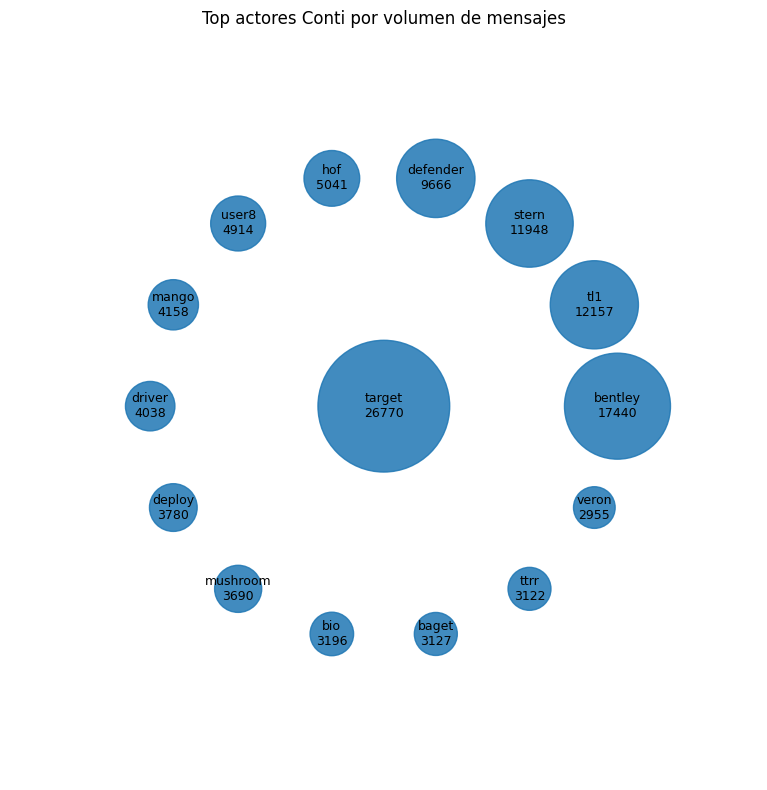

In [8]:
# Importamos numpy, la librería de Python para cálculos numéricos.
# La usamos aquí para calcular los ángulos y coordenadas del gráfico radial.
import numpy as np
import matplotlib.pyplot as plt

# Cuántos actores queremos mostrar en el gráfico.
top_n = 15

# Preparamos los datos: tomamos los 15 actores más activos.
# groupby + size nos da el número de mensajes por actor.
# sort_values → de más a menos mensajes.
# head(top_n) → solo los 15 primeros.
# reset_index(name='n_messages') convierte el resultado en DataFrame con columna 'n_messages'.
# rename → cambia el nombre de la columna 'username' a 'actor' para claridad.
df_top = (
    df.groupby('username').size()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index(name='n_messages')
    .rename(columns={'username': 'actor'})
)

# Calculamos el tamaño de cada burbuja proporcional al número de mensajes.
# Convertimos a float para poder hacer operaciones matemáticas.
vals = df_top['n_messages'].astype(float).to_numpy()

# Definimos el rango de tamaños de burbuja (en puntos cuadrados de matplotlib).
min_area, max_area = 900, 9000

# Escalamos los valores al rango [min_area, max_area] usando una fórmula de normalización:
# área = min + (valor - min_valor) * (max_area - min_area) / (max_valor - min_valor)
areas = min_area + (vals - vals.min()) * (max_area - min_area) / (vals.max() - vals.min())

# --- Layout radial: actor más activo en el centro, resto en círculo alrededor ---
n = len(df_top)

# Empezamos con todas las coordenadas en (0, 0) — es decir, en el centro.
coords = np.zeros((n, 2))

if n > 1:
    # Distribuimos los actores restantes (del índice 1 en adelante) uniformemente
    # en un círculo. linspace crea n-1 ángulos equidistantes entre 0 y 2π (360°).
    angles = np.linspace(0, 2 * np.pi, n - 1, endpoint=False)

    # Calculamos las coordenadas x e y de cada punto en el círculo unitario.
    # cos(ángulo) da la coordenada horizontal, sin(ángulo) la vertical.
    coords[1:, 0] = np.cos(angles)
    coords[1:, 1] = np.sin(angles)

# Creamos la figura y el eje del gráfico (8x8 pulgadas de tamaño).
fig, ax = plt.subplots(figsize=(8, 8))

# Dibujamos el gráfico de dispersión (scatter).
# coords[:,0] son todas las coordenadas x, coords[:,1] todas las y.
# s=areas define el tamaño de cada punto, alpha=0.85 hace los puntos ligeramente transparentes.
ax.scatter(coords[:, 0], coords[:, 1], s=areas, alpha=0.85)

# Añadimos etiquetas dentro de cada burbuja con el nombre del actor y su número de mensajes.
for (x, y), actor, count in zip(coords, df_top['actor'], df_top['n_messages']):
    ax.text(x, y, f"{actor}\n{int(count)}", ha='center', va='center', fontsize=9)

# Configuramos el aspecto visual del gráfico.
ax.set_title('Top actores Conti por volumen de mensajes')
ax.axis('off')       # Ocultamos los ejes (no necesitamos valores numéricos aquí)
ax.set_aspect('equal')  # Aseguramos que el círculo no se distorsione en elipse
ax.set_xlim(-1.6, 1.6)  # Límites del eje x para que las burbujas no queden cortadas
ax.set_ylim(-1.6, 1.6)  # Límites del eje y
plt.tight_layout()   # Ajusta márgenes automáticamente para que todo quepa bien
plt.show()           # Muestra el gráfico

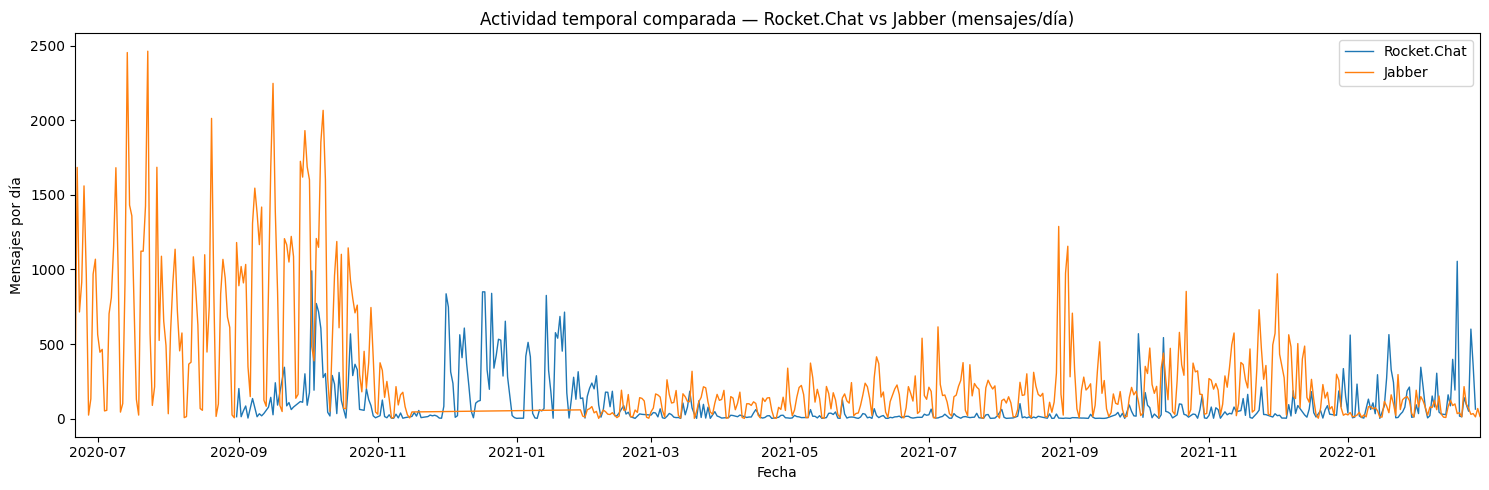

In [9]:
# Importamos matplotlib para crear el gráfico de líneas de actividad temporal.
import matplotlib.pyplot as plt
import pandas as pd

# Hacemos una copia del DataFrame para no modificar el original mientras preparamos el gráfico.
df_plot = df.copy()

# Añadimos una columna 'day' con solo la fecha (sin la hora) de cada mensaje.
# .dt.normalize() convierte el timestamp a medianoche del mismo día,
# lo que nos permite agrupar todos los mensajes de un mismo día juntos.
df_plot['day'] = df_plot['timestamp'].dt.normalize()

# Calculamos los mensajes por día para la fuente Jabber (2020 y 2021 combinados).
# Primero filtramos solo las filas de Jabber, luego agrupamos por día y contamos.
jabber_daily = (
    df_plot[df_plot['source'].isin(['jabber_2020', 'jabber_2021'])]
    .groupby('day').size().reset_index(name='n')
)

# Hacemos lo mismo para Rocket.Chat.
rocket_daily = (
    df_plot[df_plot['source'] == 'rocketchat']
    .groupby('day').size().reset_index(name='n')
)

# Calculamos el rango temporal total para usarlo como límites del eje X.
start = df_plot['day'].min()
end   = df_plot['day'].max()

# Código comentado (desactivado con #): opción para marcar el período sin datos
# entre noviembre 2020 y enero 2021 (Jabber 2020 termina, Jabber 2021 aún no empieza).
#gap_start = pd.Timestamp('2020-11-16', tz='UTC')
#gap_end   = pd.Timestamp('2021-01-29', tz='UTC')

# Creamos el gráfico de líneas: figura de 15x5 pulgadas para que la línea temporal
# sea ancha y se vean bien los detalles.
fig, ax = plt.subplots(figsize=(15, 5))

# Dibujamos una línea para Rocket.Chat y otra para Jabber.
# linewidth=1 hace las líneas delgadas para que se vean los picos de actividad.
# label= define el texto que aparecerá en la leyenda.
ax.plot(rocket_daily['day'], rocket_daily['n'], linewidth=1, label='Rocket.Chat')
ax.plot(jabber_daily['day'],  jabber_daily['n'],  linewidth=1, label='Jabber')

# Código para marcar el gap visual (desactivado).
#ax.axvspan(gap_start, gap_end, alpha=0.25, label='Gap')

# Establecemos los límites del eje X para que el gráfico empiece y termine
# exactamente en el primer y último mensaje.
ax.set_xlim(start, end)

# Etiquetas y leyenda del gráfico.
ax.set_title('Actividad temporal comparada — Rocket.Chat vs Jabber (mensajes/día)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Mensajes por día')
ax.legend()  # Muestra la leyenda con los nombres de cada línea
plt.tight_layout()
plt.show()

## 6. Guardar

In [10]:
# Guardamos el dataset limpio y unificado en formato Parquet.
# Parquet es un formato de archivo columnar muy eficiente: ocupa menos espacio
# que un CSV y se carga MUCHO más rápido (los notebooks siguientes lo cargarán
# en segundos en vez de minutos).
out_path = PROCESSED_DIR / 'conti_unified.parquet'

# to_parquet() guarda el DataFrame en el archivo Parquet.
# index=False evita guardar el índice numérico de las filas (que no aporta información).
df.to_parquet(out_path, index=False)

# Verificamos que el archivo se guardó correctamente mostrando su ruta y tamaño.
print(f'Guardado: {out_path}')
print(f'Tamaño:   {out_path.stat().st_size / 1024**2:.1f} MB')  # Convertimos bytes a MB

# Mostramos las columnas y tipos de datos para documentar el esquema del archivo guardado.
print(f'Columnas: {list(df.columns)}')
print(f'Tipos:\n{df.dtypes.to_string()}')

Guardado: data/processed/conti_unified.parquet
Tamaño:   9.8 MB
Columnas: ['timestamp', 'username', 'to_user', 'message', 'source', 'channel', 'lang']
Tipos:
timestamp    datetime64[us, UTC]
username                     str
to_user                      str
message                      str
source                       str
channel                      str
lang                         str
